# RP11: *Mixed-Integer Hyperparameter Optimization using CMA-ES*
### Jon Rodriguez and Eneko Basauri

## Introduction to *cmaes* library:

This first code cell provides a simple introduction to the *cmaes* library. In this example, we define an optimization objective function with a single global optimum at x=(3,−2), and we use a basic CMA-ES implementation (CMA) to minimize it over 100 generations. The algorithm is initialized with a mean of (0,0) and a step size σ=2. Using optimizer.ask(), an initial population of candidate solutions is generated. These candidates are then evaluated using the objective function, and the resulting solution-value pairs are fed back to the optimizer. It is worth noting that the optimizer determines the population size internally, which corresponds to λ in the standard CMA-ES formulation. For each generation, the optimizer updates its internal state based on the best solutions, and this process is repeated across all generations to gradually converge toward the optimum, as can be seen in output of the code cell below. 

In [1]:
import numpy as np
from cmaes import CMA

def objective(x):
    #global optima in x = (3,2)
    return (x[0]-3)**2+(10*(x[1]+2))**2

optimizer = CMA(mean=np.zeros(2),sigma=2)

for generation in range(100):
    solutions = []
    for _ in range(optimizer.population_size):
        x = optimizer.ask()
        value = objective(x)
        solutions.append((x,value))

        print(f"{generation=}   {value=}   {x=}")
    optimizer.tell(solutions)
    

generation=0   value=np.float64(2543.585325745885)   x=array([4.44478534, 3.04132713])
generation=0   value=np.float64(86.43439644651596)   x=array([ 1.67536851, -2.920216  ])
generation=0   value=np.float64(1599.8831615634679)   x=array([-4.51630431,  1.92859814])
generation=0   value=np.float64(1179.047619936989)   x=array([-0.85966711,  1.41196511])
generation=0   value=np.float64(56.445682390745006)   x=array([-2.92186624, -1.53764535])
generation=0   value=np.float64(1603.2350481398055)   x=array([2.04137759, 2.00289407])
generation=1   value=np.float64(26.699665235663485)   x=array([-0.87028703, -1.65764721])
generation=1   value=np.float64(3864.2424660339543)   x=array([0.19076603, 4.20995223])
generation=1   value=np.float64(11.017782287597608)   x=array([ 0.64907191, -2.23432711])
generation=1   value=np.float64(247.76056171301303)   x=array([ 0.77210762, -0.44180535])
generation=1   value=np.float64(86.33565566999069)   x=array([-1.70431157, -1.1987191 ])
generation=1   value

## Using $1 − Accuracy$ of a Neural Network as a Black-Box Objective Function:

In the experiments described in following sections, we aim to compare the performance of the naive CMA-ES and CMAwM algorithms in optimizing a black-box objective function $f(x)$ defined over a mixture of continuous and discrete variables. In this section we introduce said objective function $f(x)$ as the $1−accuracy$ of a neural network trained and evaluated on the MNIST benchmark dataset, where $x$ denotes a set of hyperparameters used during training of the NN. By minimizing this objective, the optimizer effectively performs hyperparameter optimization, as minimizing $1−accuracy$ corresponds to maximizing the neural network’s classification performance.
1) **Number of layers of the NN (`n_layers`)** — *DISCRETE*  
   Determines the depth of the convolutional neural network.  
   **Bounds:** [1, 4]

2) **Kernel size of convolutional layers (`ksize`)** — *DISCRETE*  
   Controls the receptive field of each convolutional filter. Larger kernels capture broader spatial patterns, while smaller kernels focus on local details.  
   **Bounds:** [3, 7]

3) **Batch size (`batch_size`)** — *DISCRETE*  
   Number of training samples processed in a single forward/backward pass.  
   **Bounds:** [32, 128]

4) **Learning rate (`lr`)** — *CONTINUOUS*  
   Step size for the optimizer during gradient descent. Determines how quickly the network adapts to the training data.  
   **Bounds:** [1e-5, 1e-1]

5) **Weight decay (`wd`)** — *CONTINUOUS*  
   Regularization term added to the optimizer to prevent overfitting by penalizing large weights.  
   **Bounds:** [0.0, 0.1]


In [6]:
import numpy as np
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision
import torch
import torch.optim as optim

# ================================================================
# 1. Dataset loader
# ================================================================
def get_data_loaders(batch_size):
    transform = transforms.Compose([transforms.ToTensor()])
    train_set = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transform)
    test_set = torchvision.datasets.MNIST(root="./data", train=False, download=True, transform=transform)
    train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True)
    test_loader = torch.utils.data.DataLoader(test_set, batch_size=batch_size, shuffle=False)
    return train_loader, test_loader


# ================================================================
# 2. Model definition
# ================================================================
class SimpleCNN(nn.Module):
    def __init__(self, n_layers=2, filter_size=3):
        super(SimpleCNN, self).__init__()
        layers = []
        in_channels = 1
        for _ in range(n_layers):
            layers.append(nn.Conv2d(in_channels, 16, kernel_size=filter_size, padding=filter_size // 2))
            layers.append(nn.ReLU())
            layers.append(nn.MaxPool2d(2))
            in_channels = 16
        self.conv = nn.Sequential(*layers)
        self.fc = None  # created dynamically

    def forward(self, x):
        x = self.conv(x)
        if self.fc is None:
            n_features = x.view(x.size(0), -1).size(1)
            self.fc = nn.Linear(n_features, 10).to(x.device)
        x = x.view(x.size(0), -1)
        return self.fc(x)


# ================================================================
# 3. Objective function
# ================================================================
def objective(params, epochs=1, device="cpu"):
    lr, wd, n_layers, ksize, batch_size = params
    n_layers = int(np.clip(round(n_layers), 1, 4))
    ksize = int(np.clip(round(ksize), 3, 7))
    batch_size = int(np.clip(round(batch_size), 32, 128))

    train_loader, test_loader = get_data_loaders(batch_size)
    model = SimpleCNN(n_layers, ksize).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)

    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()

    model.eval()
    correct, total = 0, 0
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        preds = model(xb).argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)
    acc = correct / total
    return 1 - acc  # minimize validation error



Additionally, because the MNIST dataset is shuffled during loading, the objective function includes a stochastic component, as illustrated in the following code cell:

In [10]:
params = [
    0.001,  # lr
    0.0001, # wd
    3,      # n_layers
    5,      # ksize
    64      # batch_size
]
print("1:")
print(f"x = {params}\nf(x)={objective(params)}")
print("2: (\n\nwith the same x)")
print(f"x = {params}\nf(x)={objective(params)}")

1:
x = [0.001, 0.0001, 3, 5, 64]
f(x)=0.03720000000000001
2: (

with the same x)
x = [0.001, 0.0001, 3, 5, 64]
f(x)=0.04169999999999996


## Performance comparison of CMA-ES and CMAwM in Mixed-Integer Hyperparameter Optimization:

This section implements the necessary functions to compare the performance of CMA-ES against CMAwM using the introduced objective function. While the baseline CMA-ES algorithm treats discrete variables as continuous—allowing them to take any real value before being rounded to the nearest integer within the objective function—the CMAwM variant explicitly accounts for the mixed (continuous and discrete) nature of the search space via the *steps* parameter. This modification allows CMAwM to better adapt to problems involving both variable types, such as the one considered in this study, and potentially improve overall optimization performance.

Using device: cpu

=== Trial 1/5 ===
[CMA-ES] Gen 0 min f(x)=0.0339 best x = [4.28744322e-02 5.66001196e-03 2.16969422e+00 4.58334546e+00
 8.02337159e+01]
[CMA-ES] Gen 1 min f(x)=0.0339 best x = [ 0.1         0.          2.3783792   4.66535236 80.5329282 ]
[CMA-ES] Gen 2 min f(x)=0.0339 best x = [1.00000000e-05 1.00000000e-01 2.20411090e+00 4.83640931e+00
 8.03375163e+01]
[CMA-ES] Gen 3 min f(x)=0.0339 best x = [1.00000000e-05 1.00000000e-01 2.30744562e+00 4.89055418e+00
 8.02838411e+01]
[CMA-ES] Gen 4 min f(x)=0.0339 best x = [ 0.1         0.          2.12947613  5.83425179 80.57162905]
[CMA-ES] Gen 5 min f(x)=0.0339 best x = [7.31227570e-02 7.65355541e-02 1.51185639e+00 5.55139839e+00
 8.07192445e+01]
[CMA-ES] Gen 6 min f(x)=0.0339 best x = [1.00000000e-05 1.00000000e-01 1.78532876e+00 5.86265322e+00
 8.03446440e+01]
[CMA-ES] Gen 7 min f(x)=0.0339 best x = [6.15161474e-02 1.38338535e-02 2.69552983e+00 5.89940273e+00
 8.07187170e+01]
[CMA-ES] Gen 8 min f(x)=0.0339 best x = [4.79243408

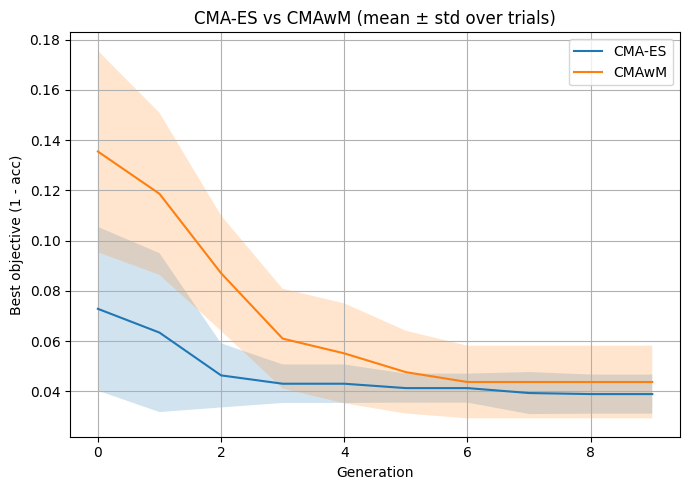


Final summary:
count    2.000000
mean     0.025650
std      0.003323
min      0.023300
25%      0.024475
50%      0.025650
75%      0.026825
max      0.028000
Name: val, dtype: float64


In [11]:
from cmaes import CMA
from cmaes import CMAwM
import pandas as pd
import matplotlib.pyplot as plt
import time

# ================================================================
# 4. CMA-ES Baseline (naive)
# ================================================================
def run_cmaes_naive(max_gen=10):
    bounds = np.array([
        [1e-5, 1e-1],   # learning rate
        [0.0, 0.1],     # weight decay
        [1, 4],         # num layers
        [3, 7],         # kernel size
        [32, 128],      # batch size
    ])
    mean = np.mean(bounds, axis=1)
    sigma = 0.5
    optimizer = CMA(mean=mean, sigma=sigma, bounds=bounds)

    best_val = float("inf")
    history = []
    for gen in range(max_gen):
        solutions = []
        for _ in range(optimizer.population_size):
            x = optimizer.ask()
            val = objective(x)
            solutions.append((x, val))
            if val < best_val:
                best_val = val
                best_x = x
        optimizer.tell(solutions)
        history.append(best_val)
        print(f"[CMA-ES] Gen {gen} min f(x)={best_val:.4f} best x = {x}")
    return history


# ================================================================
# 5. CMAwM (mixed-integer)
# ================================================================
def run_cmaes_wm(max_gen=10):
    bounds = np.array([
        [1e-5, 1e-1],   # lr
        [0.0, 0.1],     # wd
        [1, 4],         # layers
        [3, 7],         # kernel size
        [32, 128],      # batch
    ])
    steps = np.array([0.0, 0.0, 1.0, 2.0, 8.0])
    mean = np.mean(bounds, axis=1)
    sigma = 0.5
    optimizer = CMAwM(mean=mean, sigma=sigma, bounds=bounds, steps=steps)

    best_val = float("inf")
    history = []
    for gen in range(max_gen):
        solutions = []
        for _ in range(optimizer.population_size):
            x_eval, x_tell = optimizer.ask()
            val = objective(x_eval)
            solutions.append((x_tell, val))
            if val < best_val:
                best_val = val
                best_x = x_eval
        optimizer.tell(solutions)
        history.append(best_val)
        print(f"[CMAwM] Gen {gen} min f(x)={best_val:.4f} best x = {x_eval}")
    return history


# ================================================================
# 6. Multiple Trials Experiment
# ================================================================
def run_experiments(n_trials=5, max_gen=10):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")
    all_histories = []
    start_time = time.time()

    for trial in range(n_trials):
        print(f"\n=== Trial {trial+1}/{n_trials} ===")
        np.random.seed(trial)
        torch.manual_seed(trial)

        hist_naive = run_cmaes_naive(max_gen)
        hist_wm = run_cmaes_wm(max_gen)

        all_histories.append({"method": "CMA-ES", "trial": trial, "history": hist_naive})
        all_histories.append({"method": "CMAwM", "trial": trial, "history": hist_wm})

    print(f"\nTotal runtime: {time.time()-start_time:.2f}s")
    return all_histories


# ================================================================
# 7. Save results + plot
# ================================================================
def save_and_plot(histories):
    records = []
    for run in histories:
        for gen, val in enumerate(run["history"]):
            records.append({"method": run["method"], "trial": run["trial"], "generation": gen, "val": val})
    df = pd.DataFrame(records)
    df.to_csv("cmaes_results.csv", index=False)
    print("\nSaved results to cmaes_results.csv")

    summary = df.groupby(["method", "generation"])["val"].agg(["mean", "std"]).reset_index()

    plt.figure(figsize=(7,5))
    for method, grp in summary.groupby("method"):
        plt.plot(grp["generation"], grp["mean"], label=method)
        plt.fill_between(grp["generation"], grp["mean"]-grp["std"], grp["mean"]+grp["std"], alpha=0.2)
    plt.xlabel("Generation")
    plt.ylabel("Best objective (1 - acc)")
    plt.title("CMA-ES vs CMAwM (mean ± std over trials)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("convergence_plot.png")
    plt.show()

    print("\nFinal summary:")
    print(df.groupby("method")["val"].min().describe())


# ================================================================
# MAIN
# ================================================================
if __name__ == "__main__":
    histories = run_experiments(n_trials=5, max_gen=10)  # reduce for speed
    save_and_plot(histories)
